# Comparativa final de modelos

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

os.makedirs("plots/comparativa_final", exist_ok=True)

# ── Leer los tres JSONs ──────────────────────────────────────────────────────
with open("modelo_final/metricas_keras.json")   as f: mk = json.load(f)
with open("modelo_final/metricas_pytorch.json") as f: mp = json.load(f)
with open("modelo_final/metricas_xgboost.json") as f: mx = json.load(f)

# ── Extraer métricas del modelo_final de cada archivo ───────────────────────
# Keras y PyTorch guardan pipeline_log y pipeline_disc
# XGBoost guarda pipeline_nat y pipeline_ohe
# Tomamos el pipeline principal de cada uno:
#   Keras/PyTorch → pipeline_disc  (el recomendado para redes en tu proyecto)
#   XGBoost       → pipeline_nat   (categóricas nativas, pipeline lean)

def extraer(json_data, pipeline_key, modelo_key="modelo_final"):
    return json_data[modelo_key][pipeline_key]

metricas = {
    "Keras (disc)":    extraer(mk, "pipeline_disc"),
    "PyTorch (disc)":  extraer(mp, "pipeline_disc"),
    "XGBoost (nativo)":extraer(mx, "pipeline_nat"),
}

# Mostrar resumen
print(f"{'Modelo':<22} {'ROC-AUC':>8} {'PR-AUC':>8} {'F1':>8} {'Accuracy':>9}")
print("─" * 60)
for nombre, m in metricas.items():
    print(f"  {nombre:<20} {m['auc']:>8.4f} {m['pr_auc']:>8.4f} "
          f"{m['f1']:>8.4f} {m['acc']:>9.4f}")


Modelo                  ROC-AUC   PR-AUC       F1  Accuracy
────────────────────────────────────────────────────────────
  Keras (disc)           0.9242   0.8196   0.6991    0.8216
  PyTorch (disc)         0.9253   0.8217   0.7028    0.8246
  XGBoost (nativo)       0.9323   0.8388   0.7163    0.8378


In [2]:
df = pd.DataFrame([
    {
        "Modelo":   nombre,
        "Pipeline": m.get("nombre", ""),
        "ROC-AUC":  round(m["auc"],    4),
        "PR-AUC":   round(m["pr_auc"], 4),
        "F1":       round(m["f1"],     4),
        "Accuracy": round(m["acc"],    4),
    }
    for nombre, m in metricas.items()
]).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

df.to_csv("plots/comparativa_final/tabla_comparativa.csv", index=False)
print(df.to_string(index=False))


          Modelo       Pipeline  ROC-AUC  PR-AUC     F1  Accuracy
XGBoost (nativo) Final / nativo   0.9323  0.8388 0.7163    0.8378
  PyTorch (disc)   Final / disc   0.9253  0.8217 0.7028    0.8246
    Keras (disc)   Final / disc   0.9242  0.8196 0.6991    0.8216


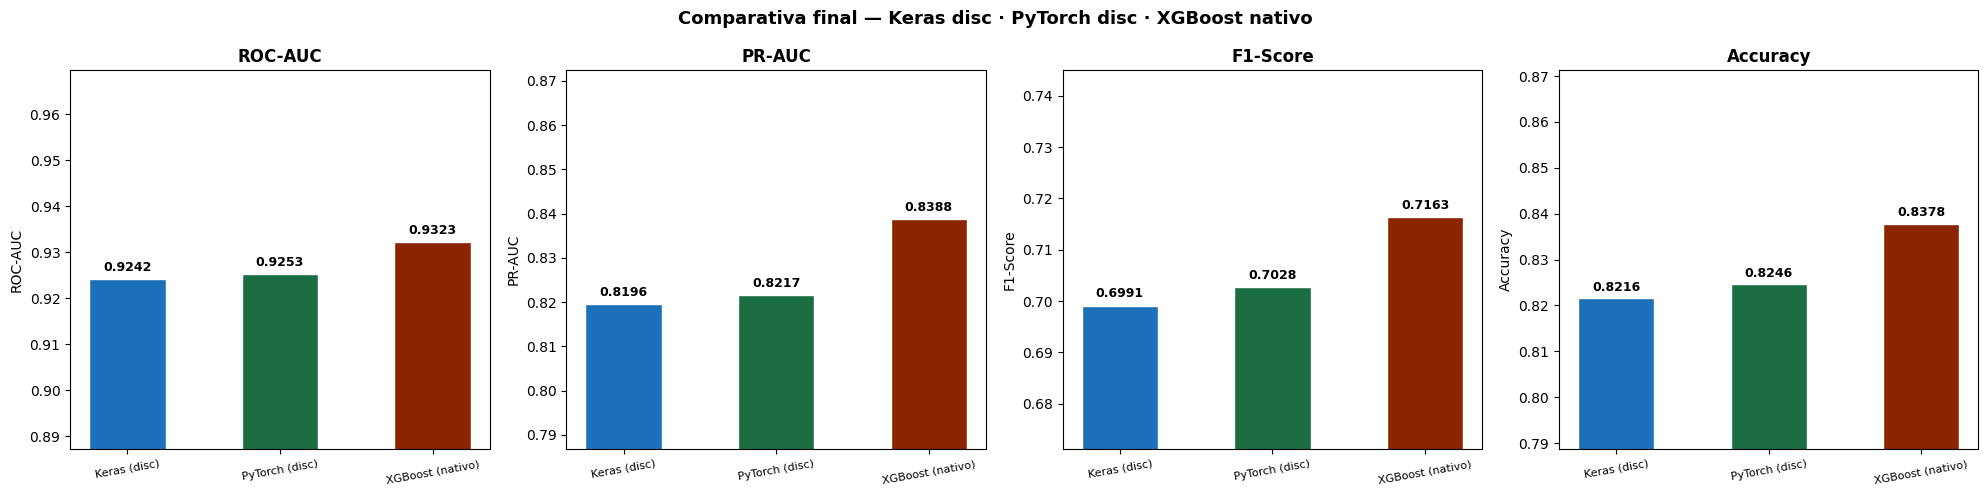

✅ plots/comparativa_final/comparativa_barras.png


In [3]:
nombres  = list(metricas.keys())
colores  = ["#1e6fba", "#1b6e44", "#8b2500"]
metricas_vals = list(metricas.values())

METRICAS_EJES = [
    ("ROC-AUC", "auc"),
    ("PR-AUC",  "pr_auc"),
    ("F1-Score","f1"),
    ("Accuracy","acc"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Comparativa final — Keras disc · PyTorch disc · XGBoost nativo",
             fontsize=13, fontweight="bold")

for ax, (titulo, key) in zip(axes, METRICAS_EJES):
    vals = [m[key] for m in metricas_vals]
    bars = ax.bar(nombres, vals, color=colores, edgecolor="white", width=0.5)
    ax.set_ylim(min(vals) * 0.96, min(max(vals) * 1.04, 1.0))
    ax.set_title(titulo, fontweight="bold")
    ax.set_ylabel(titulo)
    ax.tick_params(axis="x", labelsize=8, rotation=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("plots/comparativa_final/comparativa_barras.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ plots/comparativa_final/comparativa_barras.png")


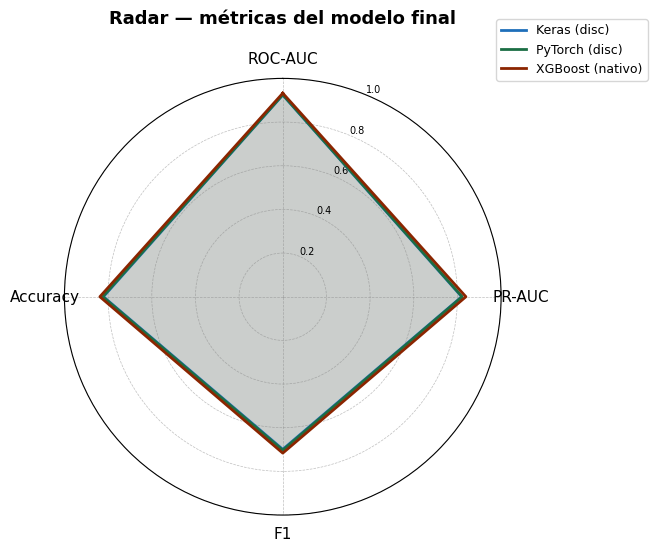

✅ plots/comparativa_final/comparativa_radar.png


In [4]:
from matplotlib.patches import FancyArrowPatch

categorias = ["ROC-AUC", "PR-AUC", "F1", "Accuracy"]
keys       = ["auc", "pr_auc", "f1", "acc"]
N          = len(categorias)
angulos    = [n / float(N) * 2 * np.pi for n in range(N)]
angulos   += angulos[:1]   # cerrar el polígono

fig, ax = plt.subplots(figsize=(7, 7),
                        subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=7)
ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)

for (nombre, m), color in zip(metricas.items(), colores):
    vals  = [m[k] for k in keys] + [m[keys[0]]]
    ax.plot(angulos, vals, color=color, linewidth=2, label=nombre)
    ax.fill(angulos, vals, color=color, alpha=0.10)

ax.set_title("Radar — métricas del modelo final",
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig("plots/comparativa_final/comparativa_radar.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ plots/comparativa_final/comparativa_radar.png")


# Interpretabilidad con SHAP